# Superstore Sales Analysis using Python

## Exploratory Data Analysis (EDA)

### Tools Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Project Objective

The objective of this project is to analyze Superstore sales data using Exploratory Data Analysis (EDA) techniques. The analysis aims to identify sales trends, customer behavior, regional performance, profitable product categories, and the impact of discounts on profit. The insights generated from this analysis can help businesses make data-driven decisions to improve sales and profitability.

## Import Libraries

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set_style("whitegrid")


## Load Dataset

In [66]:
df = pd.read_csv("../data/sales_data.csv.csv")



## Data Cleaning

In [67]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [68]:
df.shape

(9994, 13)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [70]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [71]:
df.duplicated().sum()

np.int64(17)

In [72]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [73]:
df.drop_duplicates(inplace=True)

In [74]:
df.duplicated().sum()

np.int64(0)

In [75]:
total_sales = df["Sales"].sum()

print("Total Sales:", total_sales)

Total Sales: 2296195.5903


In [76]:
total_profit = df["Profit"].sum()

print("Total Profit:", total_profit)

Total Profit: 286241.42260000005


In [77]:
total_quantity = df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 37820


In [78]:
avg_discount = df["Discount"].mean()

print("Average Discount:", avg_discount)

Average Discount: 0.15627844041294978


In [79]:
df.drop_duplicates(inplace=True)

df.shape

(9977, 13)

## Exploratory Data Analysis

### Sales by Category

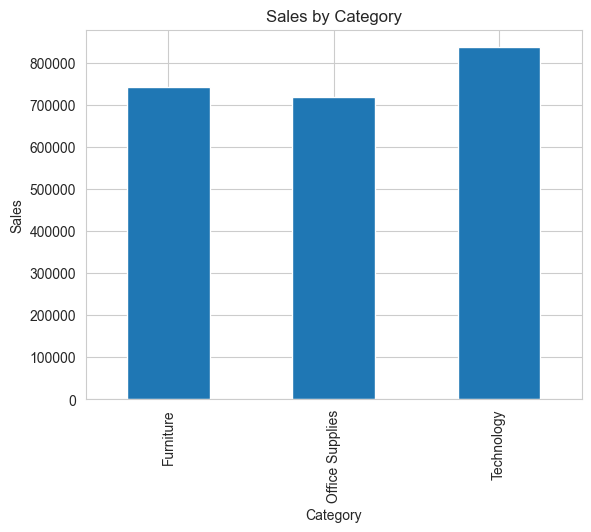

In [80]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

Technology category contributes the highest sales among all categories.

### Profit By Category

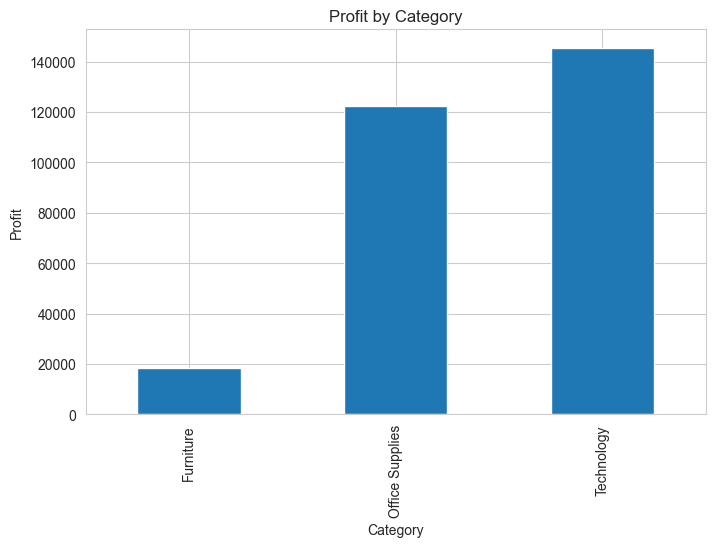

In [81]:
plt.figure(figsize=(8,5))

profit_category = df.groupby('Category')['Profit'].sum().sort_values()

profit_category.plot(kind='bar')

plt.title('Profit by Category')
plt.ylabel('Profit')

plt.show()

Technology category generates the highest profit.

### Sales By Region

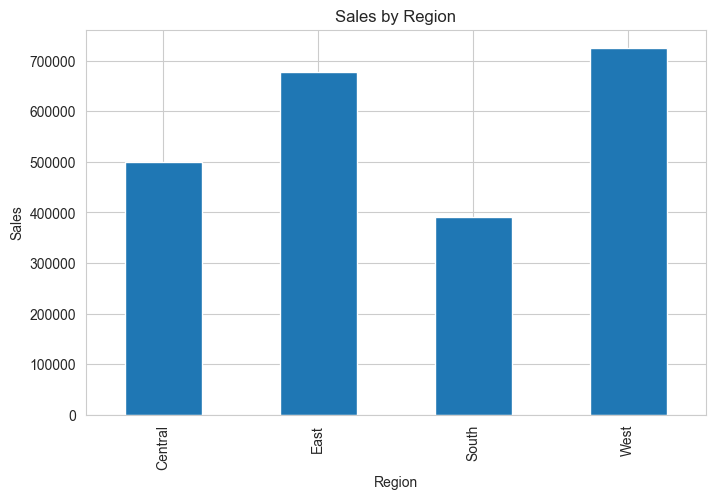

In [82]:
plt.figure(figsize=(8,5))

region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.ylabel('Sales')

plt.show()

West region contributes the highest sales.

### Profit By Region

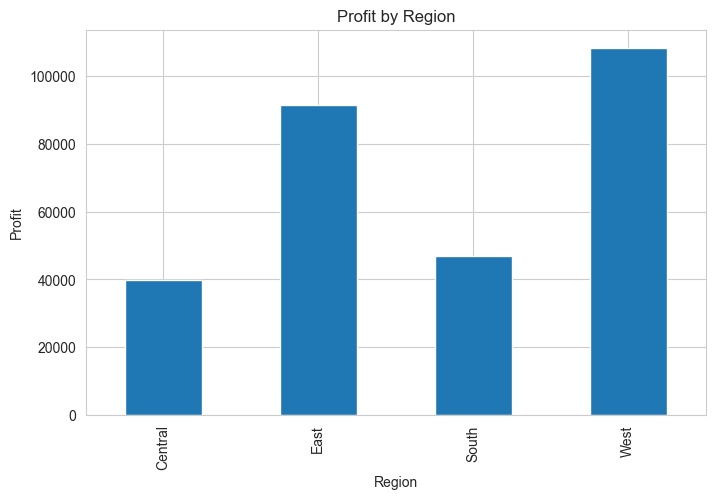

In [83]:
plt.figure(figsize=(8,5))

region_profit = df.groupby('Region')['Profit'].sum()

region_profit.plot(kind='bar')

plt.title('Profit by Region')
plt.ylabel('Profit')

plt.show()

West Region have Highest Profit. 

### Top 10 States by Sales

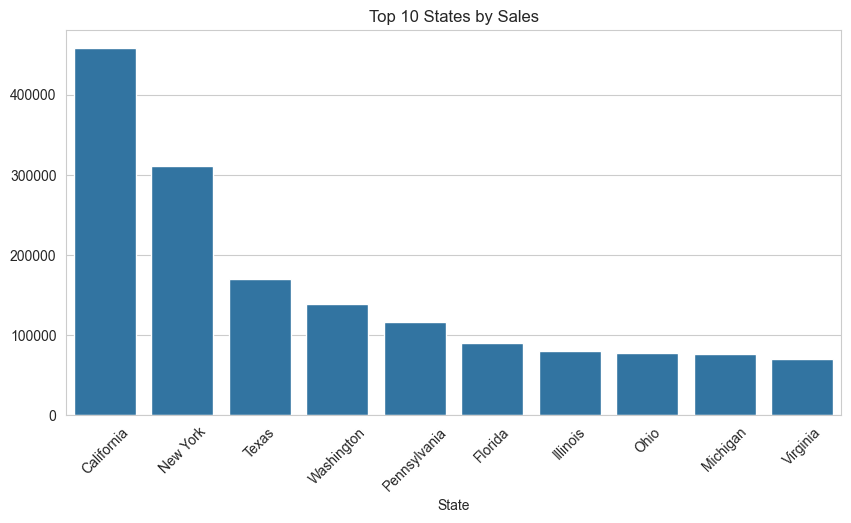

In [84]:
top_states = (
    df.groupby('State')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.xticks(rotation=45)

plt.title('Top 10 States by Sales')

plt.show()

California generated the highest sales, followed by New York and Texas. These states represent the strongest markets and should be prioritized for future business expansion and marketing efforts.

### Top 10 Cities by Profit

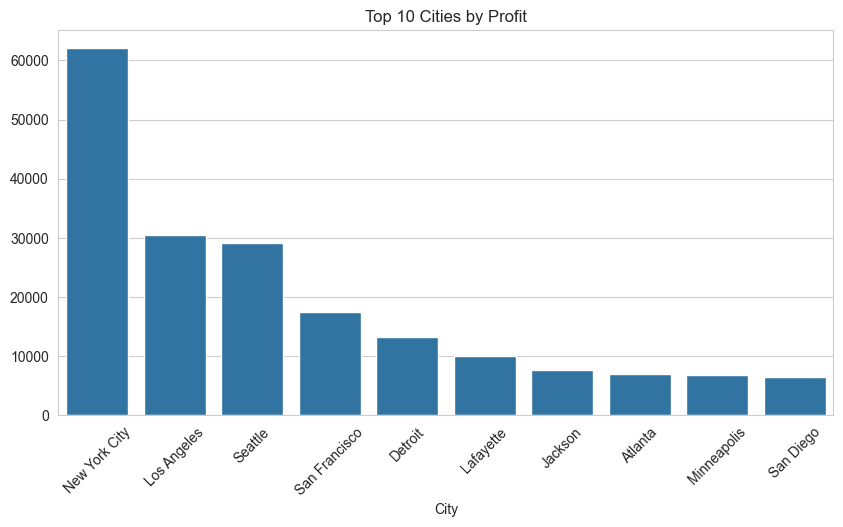

In [85]:
top_cities = (
    df.groupby('City')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_cities.index,
    y=top_cities.values
)

plt.xticks(rotation=45)

plt.title('Top 10 Cities by Profit')

plt.show()

### Discount vs Profit

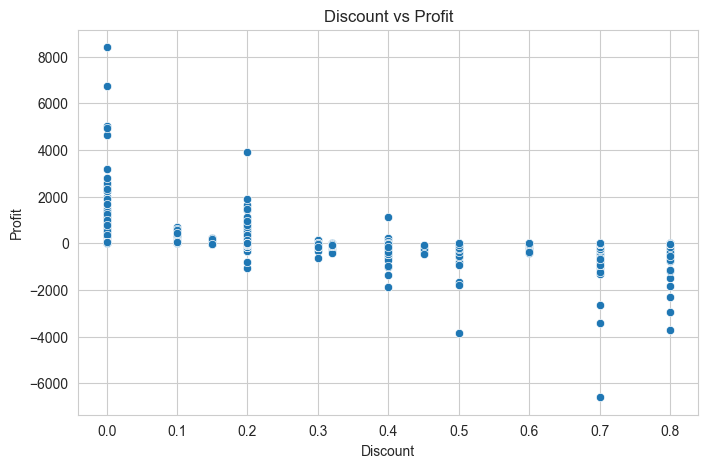

In [86]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title('Discount vs Profit')

plt.show()

Higher discounts are generally associated with lower profits and, in many cases, negative profits. This indicates that excessive discounting can significantly reduce business profitability.

### Sales Distribution

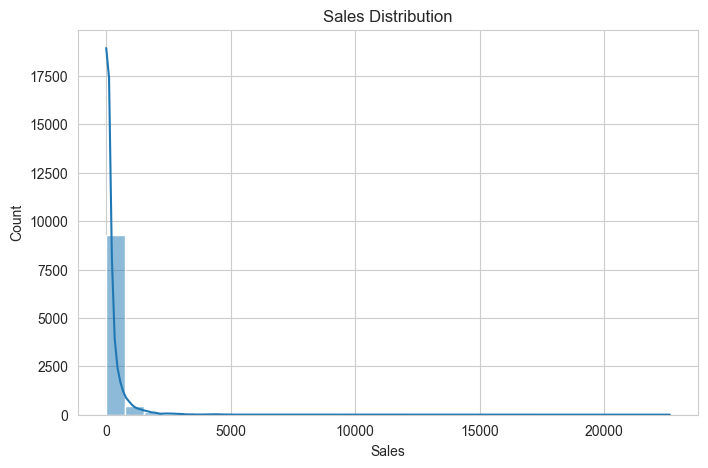

In [87]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Sales'],
    bins=30,
    kde=True
)

plt.title('Sales Distribution')

plt.show()

### Quantity Distribution

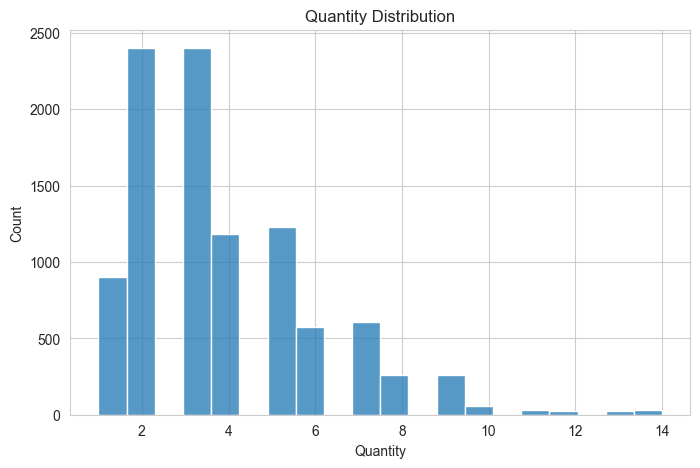

In [88]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Quantity'],
    bins=20
)

plt.title('Quantity Distribution')

plt.show()

### Sales Contribution by Segment

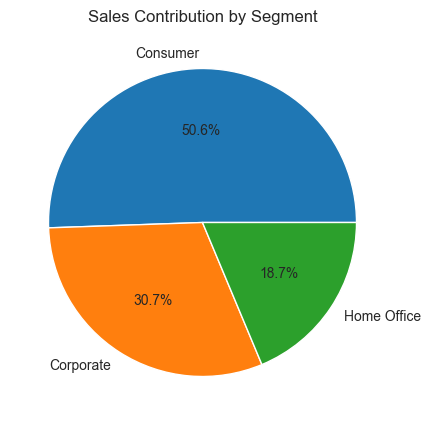

In [89]:
segment_sales = (
    df.groupby('Segment')['Sales']
      .sum()
)

plt.figure(figsize=(8,5))

segment_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')

plt.title('Sales Contribution by Segment')

plt.show()

The Consumer segment contributes more than half of total sales, making it the most important customer segment for revenue generation.

### Profit by Sub-Category

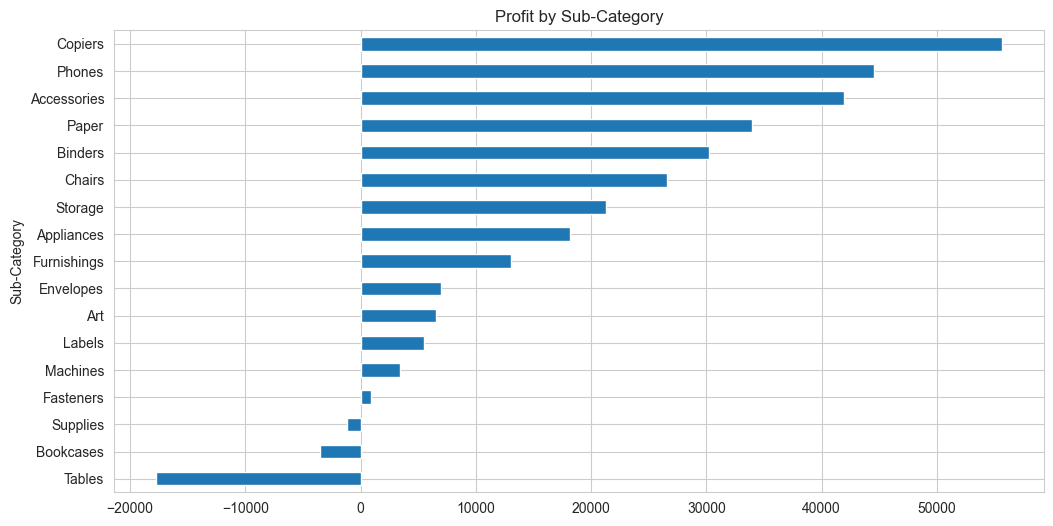

In [90]:
plt.figure(figsize=(12,6))

sub_profit = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values()
)

sub_profit.plot(kind='barh')

plt.title("Profit by Sub-Category")

plt.show()

### Sales by Ship Mode

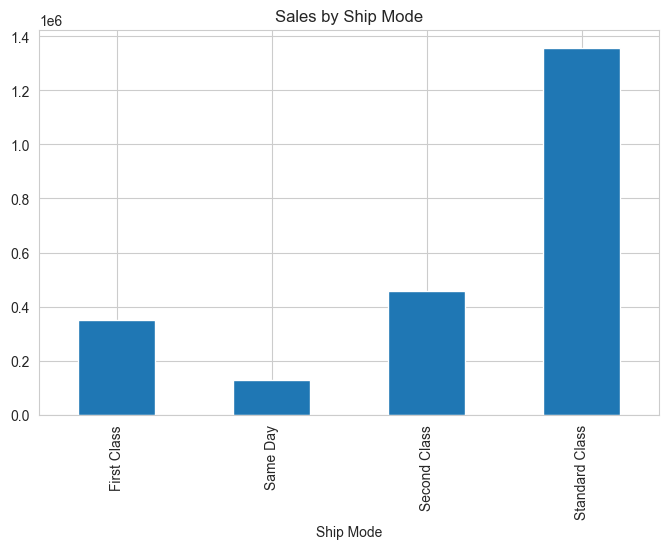

In [91]:
plt.figure(figsize=(8,5))

ship_sales = df.groupby('Ship Mode')['Sales'].sum()

ship_sales.plot(kind='bar')

plt.title('Sales by Ship Mode')

plt.show()

### Correlation Heatmap

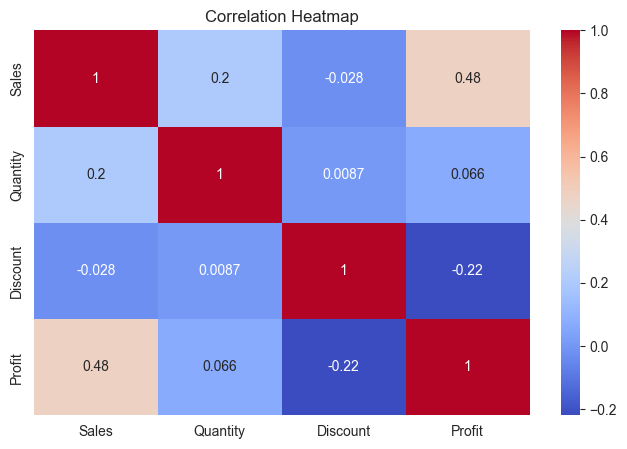

In [92]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Sales','Quantity','Discount','Profit']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

## Business Insights 
1. Technology category generated the highest overall sales.

2. The West region recorded the highest sales.

3. Consumer segment contributed the largest share of sales.

4. Higher discounts generally reduced profit.

5. Standard Class was the most commonly used shipping mode.

6. Sales varied significantly across states.

7. A few sub-categories generated most of the overall profit.

8. Sales and Profit showed a positive correlation, while Discount had a negative correlation with Profit.

## Conclusion
The Exploratory Data Analysis of the Superstore dataset revealed important business insights related to sales, profit, customer segments, product categories, and regional performance. The Technology category and the West region were the strongest contributors to sales. Higher discounts negatively impacted profit, while increased sales generally led to higher profitability. These insights can support data-driven business decisions and improve overall business performance.

## Business Recommendations
• Focus marketing efforts on Technology products.

• Reduce excessive discounts to improve profit margins.

• Expand successful strategies used in the West region.

• Promote high-profit sub-categories.

• Optimize sales in low-performing states.